In [1]:
# -----------------------------
# Import necessary libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# -----------------------------
# File paths
# -----------------------------
orders_file = Path(
    r"D:\Data_Science\Projects\Portfolio_Projects\E-commerce-Sales-Delivery-and-Customer-Satisfaction\Dataset\Analysis_Outputs\Q1_top_categories\Top_10_categories_by_orders.csv"
)

revenue_file = Path(
    r"D:\Data_Science\Projects\Portfolio_Projects\E-commerce-Sales-Delivery-and-Customer-Satisfaction\Dataset\Analysis_Outputs\Q1_top_categories\Top_10_categories_by_revenue.csv"
)

# -----------------------------
# Load data
# -----------------------------
df_orders = pd.read_csv(orders_file)
df_revenue = pd.read_csv(revenue_file)

In [3]:
# -----------------------------
# Clean labels
# -----------------------------
def clean_category_labels(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace("_", " ", regex=False)
        .str.title()
    )

df_orders["product_category"] = clean_category_labels(df_orders["product_category"])
df_revenue["product_category"] = clean_category_labels(df_revenue["product_category"])

# Sort for horizontal bar charts
df_orders = df_orders.sort_values("total_orders", ascending=True)
df_revenue = df_revenue.sort_values("total_revenue", ascending=True)

In [4]:
# -----------------------------
# Dark theme styling
# -----------------------------
BG = "#111111"
FG = "white"
BAR = "#4cc9f0"
BAR_2 = "#f72585"

plt.rcParams["figure.facecolor"] = BG
plt.rcParams["axes.facecolor"] = BG
plt.rcParams["savefig.facecolor"] = BG
plt.rcParams["text.color"] = FG
plt.rcParams["axes.labelcolor"] = FG
plt.rcParams["xtick.color"] = FG
plt.rcParams["ytick.color"] = FG
plt.rcParams["font.size"] = 13

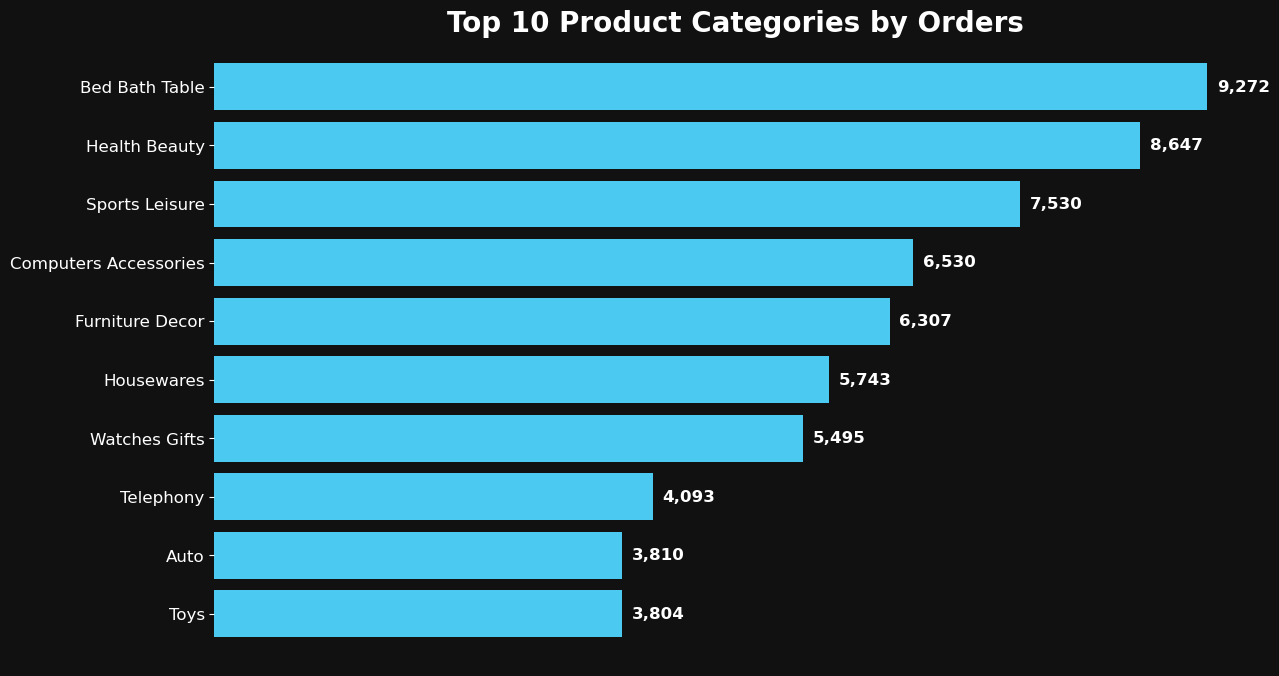

In [5]:
# -----------------------------
# Plot 1: Top 10 categories by orders
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(df_orders["product_category"], df_orders["total_orders"], color=BAR)

ax.set_title("Top 10 Product Categories by Orders", fontsize=20, pad=25, weight="bold", y=0.95)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", length=0)

for bar in bars:
    value = int(bar.get_width())
    ax.text(
        value + max(df_orders["total_orders"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        ha="left",
        fontsize=12,
        color=FG,
        weight="bold"
    )

plt.tight_layout()
plt.show()

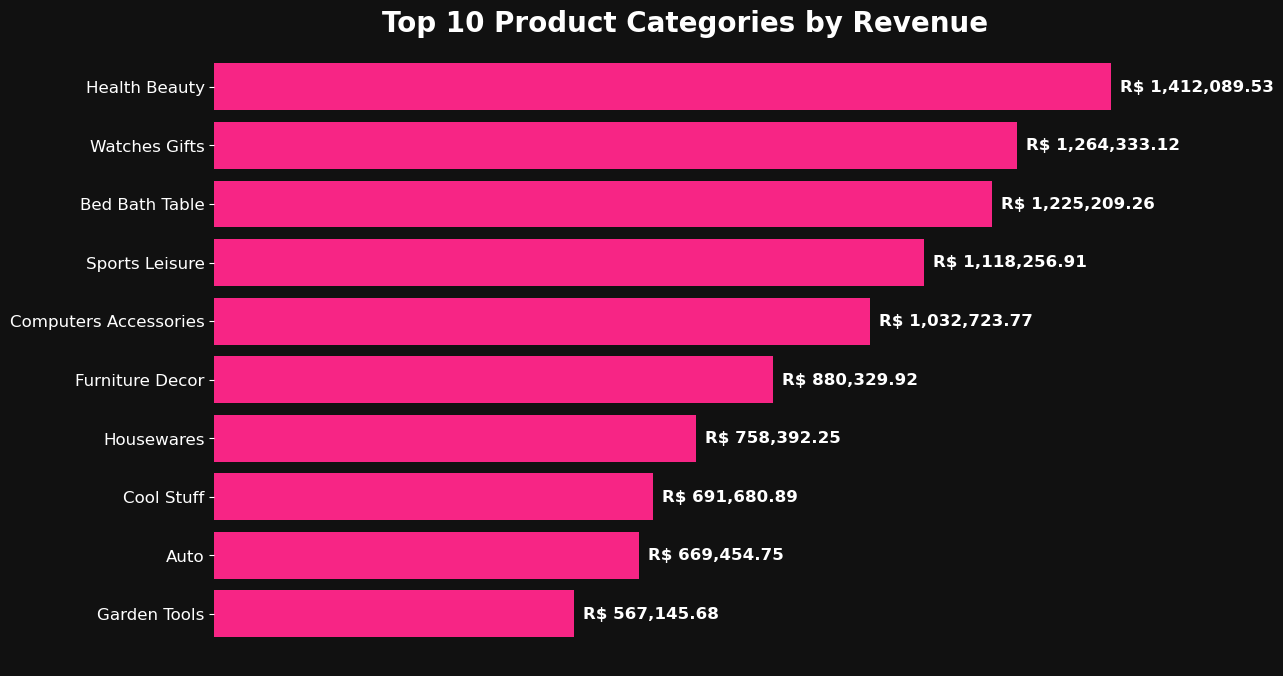

In [6]:
# -----------------------------
# Plot 2: Top 10 categories by revenue
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(df_revenue["product_category"], df_revenue["total_revenue"], color=BAR_2)

ax.set_title("Top 10 Product Categories by Revenue", fontsize=20, pad=25, weight="bold", y=0.95)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", length=0)

for bar in bars:
    value = bar.get_width()
    ax.text(
        value + max(df_revenue["total_revenue"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {value:,.2f}",
        va="center",
        ha="left",
        fontsize=12,
        color=FG,
        weight="bold"
    )

plt.tight_layout()
plt.show()